# Decision Tree Classification on Iris Dataset

This notebook builds a decision tree classifier on the Iris dataset, evaluates performance, and visualizes the trained tree.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')

In [6]:
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name='target')

print('Feature preview:')
print(X_iris.head())
print('')
print('Target distribution:')
print(pd.Series(y_iris).map(dict(enumerate(iris.target_names))).value_counts())

Feature preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target distribution:
target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Train / Test Split

In [7]:
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print('Training set shape:', X_train_iris.shape)
print('Test set shape:', X_test_iris.shape)

Training set shape: (120, 4)
Test set shape: (30, 4)


## Decision Tree Training and Evaluation

In [8]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_iris, y_train_iris)
y_pred_iris = clf.predict(X_test_iris)

print('Iris Classification Accuracy:', accuracy_score(y_test_iris, y_pred_iris))
print('Classification Report:')
print(classification_report(y_test_iris, y_pred_iris, target_names=iris.target_names))
print('Confusion Matrix:')
print(confusion_matrix(y_test_iris, y_pred_iris))

Iris Classification Accuracy: 0.9333333333333333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


## Visualize Decision Tree

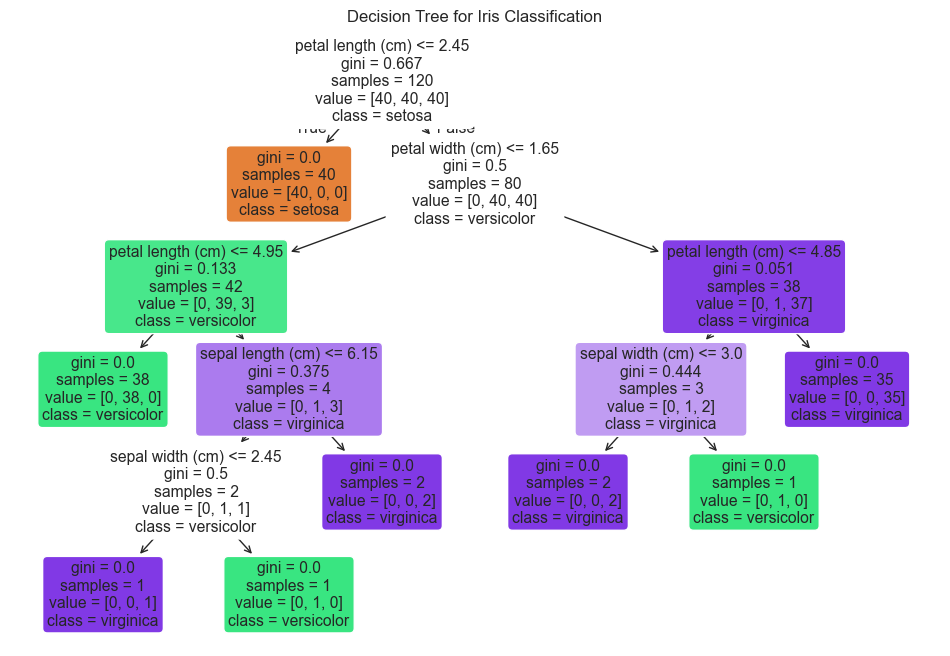

In [9]:
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title('Decision Tree for Iris Classification')
plt.show()